In [ ]:
import pandas as pd
import numpy as  np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

In [ ]:
import gdown

In [ ]:

file_id = "1-AlW7oNJHaqi3xk_9dWHUS52Dzl_FmFW"
url = f"https://drive.google.com/uc?id={file_id}"

# Download to Colab’s ephemeral storage (not your laptop)
gdown.download(url)

Downloading...
From (original): https://drive.google.com/uc?id=1-AlW7oNJHaqi3xk_9dWHUS52Dzl_FmFW
From (redirected): https://drive.google.com/uc?id=1-AlW7oNJHaqi3xk_9dWHUS52Dzl_FmFW&confirm=t&uuid=4512225f-7b93-484e-8c3e-bb297223147c
To: /content/train_data.csv
100%|██████████| 635M/635M [00:08<00:00, 72.7MB/s]


'train_data.csv'

In [ ]:
file_id = "1-8TsrqTRFP-q9TM-6HinhO0ZVXFHq9TB"
url = f"https://drive.google.com/uc?id={file_id}"

# Download to Colab’s ephemeral storage (not your laptop)
gdown.download(url)

Downloading...
From: https://drive.google.com/uc?id=1-8TsrqTRFP-q9TM-6HinhO0ZVXFHq9TB
To: /content/test_data.csv
100%|██████████| 15.6M/15.6M [00:01<00:00, 10.3MB/s]


'test_data.csv'

In [ ]:

file_id = "1I9aPAvvYgQWdHGKtnd7IeTGXpx8vOm4h"
url = f"https://drive.google.com/uc?id={file_id}"

# Download to Colab’s ephemeral storage (not your laptop)
gdown.download(url)

Downloading...
From: https://drive.google.com/uc?id=1I9aPAvvYgQWdHGKtnd7IeTGXpx8vOm4h
To: /content/title_brand.csv
100%|██████████| 97.3M/97.3M [00:02<00:00, 38.5MB/s]


'title_brand.csv'

In [ ]:
df = pd.read_csv('/content/train_data.csv')

/tmp/ipython-input-3885680196.py:1: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/content/train_data.csv')


In [ ]:
df.head(10)

,overall,vote,verified,reviewTime,reviewerID,asin,style,reviewerName,reviewText,summary,unixReviewTime
0,2,NaN,False,2016-11-11,A2OSUEZJIN7BI,0511189877,NaN,Chris,I have an older URC-WR7 remote and thought thi...,Cannot Learn,1478822400
1,5,NaN,True,2016-06-06,A2NETQRG6JHIG7,0511189877,NaN,Qrysta White,First time I've EVER had a remote that needed ...,zero programming needed! Miracle!?,1465171200
2,4,NaN,True,2016-03-10,A12JHGROAX49G7,0511189877,NaN,Linwood,Got them and only 2 of them worked. company ca...,Works Good and programs easy.,1457568000
3,5,NaN,True,2016-01-14,A1KV65E2TMMG6F,0511189877,NaN,Dane Williams,I got tired of the remote being on the wrong s...,Same as TWC remote,1452729600
4,5,NaN,True,2016-10-20,A280POPEWI0NSA,0594459451,NaN,Kristina H.,After purchasing cheap cords from another webs...,Good Quality Cord,1476921600
5,5,NaN,True,2016-06-18,A2KTAT1Y3VRVSJ,0594459451,NaN,MnMMom3,This is a great charging cable for the Nook. ...,Better than original charger!,1466208000
6,5,NaN,True,2016-02-11,A1CHTT6E3NV5YL,0594459451,NaN,Amazon Shopper,The 90 degree connector is a bonus that allows...,Works great on my Wife's older model Nook Color.,1455148800
7,2,NaN,True,2016-04-02,A1TI6WQ69ST707,0594481902,NaN,kyle,I bought this thinking it would be a great rep...,Good enough to charge and wipe an older nook b...,1459555200
8,4,NaN,True,2016-01-10,A38NYFVE0FCZRG,0594481902,NaN,S. Artist,It works! I was skeptical about ordering it b...,"It works, but it costs $30! Generic USB wall ...",1452384000
9,5,NaN,True,2016-09-19,A2LLAAYS88V96P,0594296420,NaN,Tabatha,Brand name adapter this is just like the one y...,Brand name adapter this is just like the one y...,1474243200


In [ ]:
print(df['overall'].value_counts())

overall
5    461485
4    156514
1     82950
3     81239
2     56756
Name: count, dtype: int64


/tmp/ipython-input-4038098782.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='overall', data=df, palette='coolwarm')


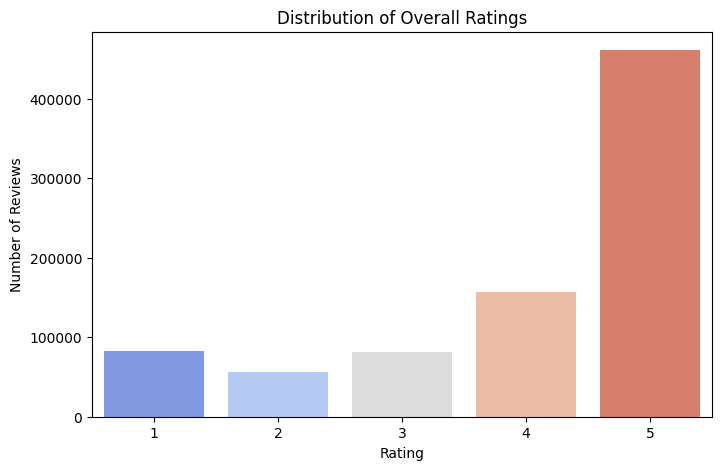

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(x='overall', data=df, palette='coolwarm')
plt.title('Distribution of Overall Ratings')
plt.xlabel('Rating')
plt.ylabel('Number of Reviews')
plt.show()


In [ ]:
print(df['overall'].value_counts(normalize=True))

overall
5    0.550078
4    0.186561
1    0.098874
3    0.096835
2    0.067652
Name: proportion, dtype: float64


### Balance Analysis of the `overall` Column

The dataset is **imbalanced**:
- 5-star reviews dominate (≈55% of total).
- Lower ratings (1–3 stars) each form less than 10% of the data.

If the task is **classification** (e.g., predicting discrete rating categories or sentiment),  
balancing is **recommended** to prevent the model from being biased toward the majority class (5-star).
- If some classes appear much more frequently than others (for example, 60% of reviews are 5-star), the model can achieve high accuracy just by always predicting the majority class.
- Minority classes (like 1-star reviews) might be ignored during training.

If the task is **regression** (predicting a continuous rating value),  
balancing is **not needed**, since each sample contributes proportionally to the regression loss function.

There are no “classes” to balance — each data point contributes to the total loss based on its distance from the predicted value.

- The model minimizes errors such as **Mean Squared Error (MSE)**:
$$
\text{MSE} = \frac{1}{n} \sum_i (y_i - \hat{y}_i)^2
$$

In [ ]:
df.isnull().sum()

,0
overall,0
vote,647476
verified,0
reviewTime,0
reviewerID,0
asin,0
style,348331
reviewerName,227
reviewText,0
summary,76


In [ ]:
def categorize_sentiment(rating):
    if rating in [4, 5]:
        return 'positive'
    elif rating == 3:
        return 'neutral'
    else:
        return 'negative'
df['sentiment'] = df['overall'].apply(categorize_sentiment)
df['sentiment'].value_counts()

,count
sentiment,
positive,617999
negative,139706
neutral,81239


In [ ]:
from wordcloud import WordCloud, STOPWORDS
import string

# Define your own stopwords
stopwords = set(STOPWORDS)

In [ ]:
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))
print(len(stop_words))

198


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
stop_words.update([
    # your existing ones
    'amazon', 'product', 'use', 'one', 'get', 'used', 'case',

    # generic verbs / fillers
    'make', 'take', 'put', 'go', 'come', 'want', 'would', 'could', 'need', 'buy', 'thing', 'way', 'see', 'know', 'look', 'got', 'give', 'keep',

    # quantity / reference
    'first', 'second', 'time', 'day', 'month', 'year', 'hour', 'week', 'set', 'lot', 'bit',

    # neutral nouns
    'device', 'unit', 'item', 'part', 'cable', 'plug', 'adapter',

    # platform words
    'review', 'purchase', 'order', 'shipping', 'delivery', 'bought', 'seller', 'arrived', 'received', 'returned', 'return',

    # pronouns / contractions
    'im', 'ive', 'you', 'your', 'they', 'them', 'we', 'us', 'he', 'she', 'it', 'this', 'that', 'these', 'those', 'its', 'cant', 'didnt', 'doesnt', 'dont', 'wasnt', 'isnt', 'arent', 'wont', 'wouldnt', 'shouldnt',

    # formatting / leftovers
    'br', 'nbsp', 'u', 'n', 'etc', 'also', 'even', 'still', 'much', 'really', 'well', 'back', 'since', 'however', 'though', 'yet'
])

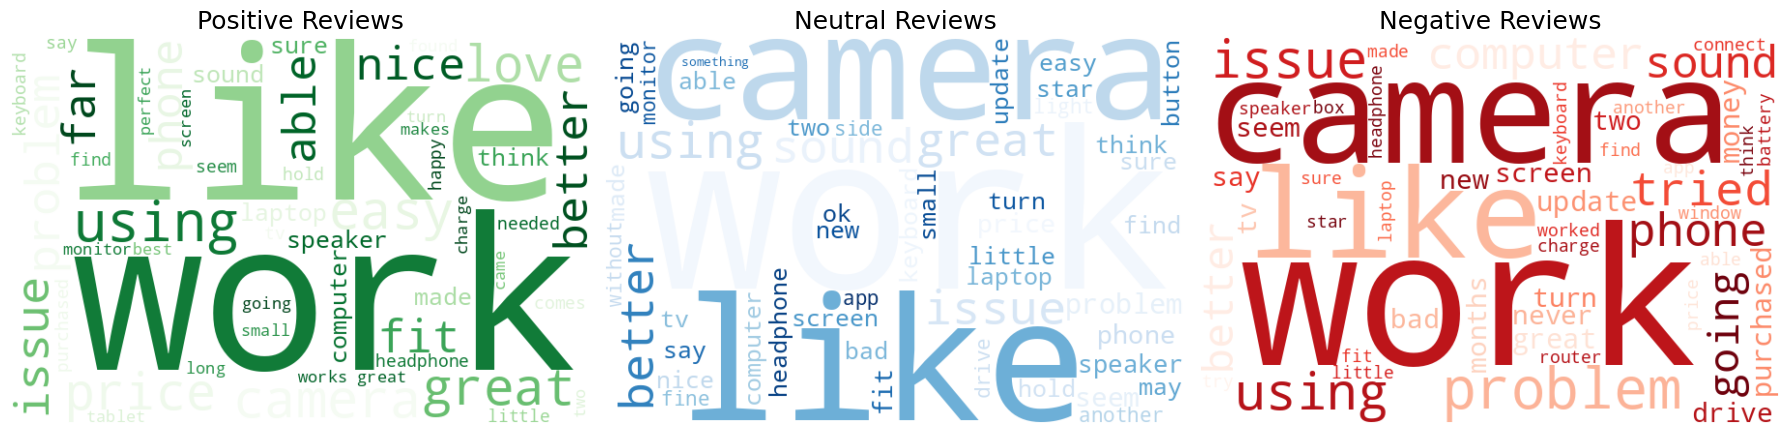

In [ ]:
def clean_text(text):
    text = str(text).lower()
    text = text.translate(str.maketrans('', '', string.punctuation))
    return text

fig, axes = plt.subplots(1, 3, figsize=(18, 8))
sentiments = ['positive', 'neutral', 'negative']
colors = ['Greens', 'Blues', 'Reds']

for i, sentiment in enumerate(sentiments):
    subset = df[df['sentiment'] == sentiment]
    if subset.empty:
        axes[i].text(0.5, 0.5, f"No {sentiment} reviews", ha='center', va='center', fontsize=16)
        axes[i].axis('off')
        continue

    text = " ".join(subset['reviewText'].dropna().apply(clean_text))
    wc = WordCloud(
        width=600,
        height=400,
        background_color='white',
        stopwords=stop_words,
        colormap=colors[i],
        max_words=50,

    ).generate(text)

    axes[i].imshow(wc, interpolation='bilinear')
    axes[i].axis('off')
    axes[i].set_title(f"{sentiment.capitalize()} Reviews", fontsize=18)

plt.tight_layout()
plt.show()

### summary shows better positive nad negative words

[nltk_data] Downloading package wordnet to /root/nltk_data...


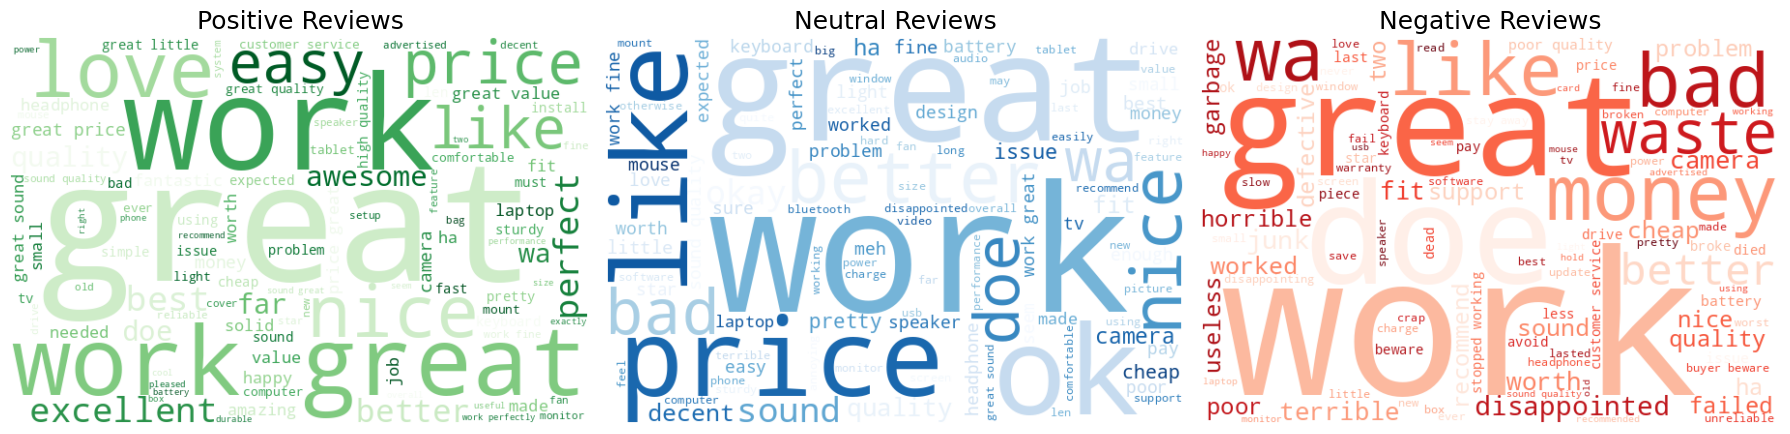

In [ ]:
import nltk
from nltk.stem import WordNetLemmatizer
nltk.download('wordnet')

lemmatizer = WordNetLemmatizer()

def clean_text_lemma(text):
    text = str(text).lower()
    text = text.translate(str.maketrans('', '', string.punctuation))
    return " ".join(lemmatizer.lemmatize(word) for word in text.split())

fig, axes = plt.subplots(1, 3, figsize=(18, 8))
sentiments = ['positive', 'neutral', 'negative']
colors = ['Greens', 'Blues', 'Reds']

for i, sentiment in enumerate(sentiments):
    subset = df[df['sentiment'] == sentiment]
    if subset.empty:
        axes[i].text(0.5, 0.5, f"No {sentiment} reviews", ha='center', va='center', fontsize=16)
        axes[i].axis('off')
        continue

    text = " ".join(subset['summary'].dropna().apply(clean_text_lemma))
    wc = WordCloud(
        width=600,
        height=400,
        background_color='white',
        stopwords=stop_words,
        colormap=colors[i],
        max_words=100,

    ).generate(text)

    axes[i].imshow(wc, interpolation='bilinear')
    axes[i].axis('off')
    axes[i].set_title(f"{sentiment.capitalize()} Reviews", fontsize=18)

plt.tight_layout()
plt.show()

In [ ]:
df['vote'] = pd.to_numeric(df['vote'], errors='coerce').fillna(0)

top10 = (
    df.groupby('reviewerName')['vote']
      .sum()
      .sort_values(ascending=False)
      .head(10)
      .reset_index()
)

top10.columns = ['Reviewer Name', 'Total Votes']

# Display
top10

,Reviewer Name,Total Votes
0,Amazon Customer,28871.0
1,Benson Leung,4572.0
2,Michael,3710.0
3,Mike,3000.0
4,Kindle Customer,2927.0
5,John,2730.0
6,Dave,2230.0
7,David,2194.0
8,Chris,2060.0
9,Steve,2046.0


### Top 10 Most Helpful Reviewers

The following table shows the **top 10 reviewers** ranked by the **total number of helpful votes** received across all their reviews.  
For each reviewer, the total vote value is the sum of all votes on their reviews.


---

### Interpretation
- **Amazon Customer** dominates the list with over **28k votes**, likely representing reviews from anonymous or default-named users.
- Other top contributors such as **Benson Leung** and **Michael** have thousands of votes, indicating that their reviews are widely trusted or frequently marked as helpful.
- The list suggests that a small subset of reviewers contribute the majority of influential or useful feedback on the platform.

**Conclusion:**  
These top reviewers have a significant impact on buyer decisions, making them valuable voices within the electronic products review community.

In [ ]:
brand_data = pd.read_csv('title_brand.csv')

In [ ]:
brand_data.head()

,asin,title,brand
0,0011300000,Genuine Geovision 1 Channel 3rd Party NVR IP S...,GeoVision
1,0043396828,"Books ""Handbook of Astronomical Image Processi...",33 Books Co.
2,0060009810,One Hot Summer,Visit Amazon's Carolina Garcia Aguilera Page
3,0060219602,Hurray for Hattie Rabbit: Story and pictures (...,Visit Amazon's Dick Gackenbach Page
4,0060786817,sex.lies.murder.fame.: A Novel,Visit Amazon's Lolita Files Page


In [ ]:
five_star = df[df['overall'] == 5]

# --- Step 2: Count how many 5-star reviews each product has ---
five_star_counts = (
    five_star.groupby('asin')
    .size()
    .reset_index(name='five_star_count')
)
product_info = df[['asin', 'summary']].drop_duplicates(subset='asin')

top_products = (
    five_star_counts
    .merge(product_info, on='asin', how='left')
    .sort_values('five_star_count', ascending=False)
    .head(10)
)

# --- Step 4: Add Amazon product link ---
top_products['amazon_link'] = "https://www.amazon.com/dp/" + top_products['asin']

# --- Step 5: Reorder and rename columns ---
top_products = top_products[['asin','five_star_count', 'amazon_link']]
# --- Step 6: Display the table ---
top_products = top_products.merge(brand_data,on= 'asin',how = 'left')

In [ ]:
top_products

,asin,five_star_count,amazon_link,title,brand
0,B010OYASRG,1163,https://www.amazon.com/dp/B010OYASRG,OontZ Angle 3 Enhanced Stereo Edition IPX5 Spl...,Cambridge Soundworks
1,B00L0YLRUW,659,https://www.amazon.com/dp/B00L0YLRUW,NETGEAR N300 WiFi Range Extender (EX2700),NETGEAR
2,B01DA0YCNC,600,https://www.amazon.com/dp/B01DA0YCNC,Roku Streaming Stick (3600R) - HD Streaming Pl...,Roku
3,B000VS4HDM,598,https://www.amazon.com/dp/B000VS4HDM,StarTech USB 2.0 to SATA IDE Adapter (USB2SATA...,StarTech
4,B0043T7FXE,552,https://www.amazon.com/dp/B0043T7FXE,Logitech M570 Wireless Trackball Mouse &ndash;...,Logitech
5,B00OBRE5UE,529,https://www.amazon.com/dp/B00OBRE5UE,Samsung 850 EVO 500GB 2.5-Inch SATA III Intern...,Samsung
6,B00S9SGNNS,471,https://www.amazon.com/dp/B00S9SGNNS,ASUS Tri-Band Gigabit (AC3200) WiFi Router (Up...,Asus
7,B000WYVBR0,448,https://www.amazon.com/dp/B000WYVBR0,VideoSecu ML531BE TV Wall Mount for Most 27&qu...,VideoSecu
8,B00P7EVST6,433,https://www.amazon.com/dp/B00P7EVST6,Arlo - Wireless Home Security Camera System | ...,"Arlo Technologies, Inc"
9,B00OAJ412U,431,https://www.amazon.com/dp/B00OAJ412U,Samsung 850 EVO 250GB 2.5-Inch SATA III Intern...,Samsung


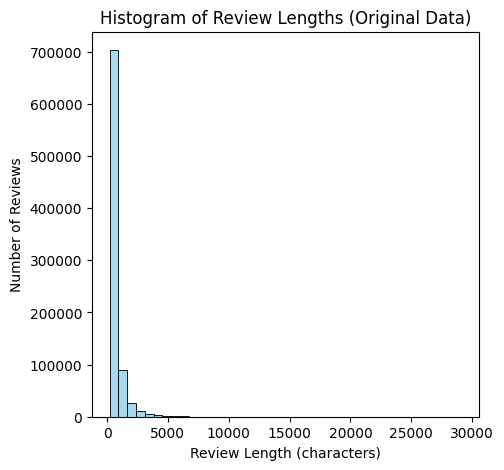

In [ ]:

# --- Step 1: Compute length of each review ---
df['text_length'] = df['reviewText'].astype(str).apply(len)

# --- Step 2: Plot histogram of all text lengths ---
plt.figure(figsize=(5,5))
sns.histplot(df['text_length'], bins=40,  color='skyblue')
plt.title('Histogram of Review Lengths (Original Data)')
plt.xlabel('Review Length (characters)')
plt.ylabel('Number of Reviews')
plt.show()

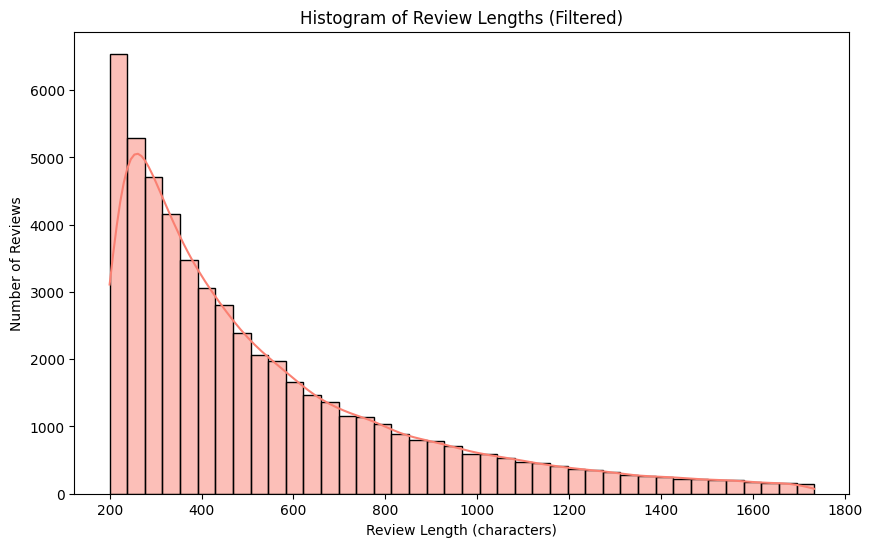

In [ ]:
low_threshold = 20
high_threshold = df['text_length'].quantile(0.95)  # keep 95% of data

df = df[(df['text_length'] >= low_threshold) & (df['text_length'] <= high_threshold)]
# Filter dataset
filtered_df = df[df['overall'] == 2].copy()

# --- Step 4: Plot histogram again (filtered) ---
plt.figure(figsize=(10,6))
sns.histplot(filtered_df['text_length'], bins=40, kde=True, color='salmon')
plt.title('Histogram of Review Lengths (Filtered)')
plt.xlabel('Review Length (characters)')
plt.ylabel('Number of Reviews')
plt.show()

## Limiting Text Length in NLP Models

### 1. Why Text Length Matters
When modeling text (e.g., for sentiment classification or review analysis), the number of characters or tokens in each document can vary widely — from a few words to several paragraphs.  
However, **most NLP models require inputs of consistent or bounded length** for computational and training stability reasons.

---

### 2. Reasons for Limiting Text Length

| Reason | Explanation |
|--------|--------------|
|**Computational Efficiency** | Processing very long texts increases training time and memory use dramatically. Each extra token adds more operations. |
|**Memory Constraints** | Deep models like RNNs and Transformers must store hidden states or attention weights for each token. This quickly consumes GPU memory. |
|**Gradient Stability** | In sequence models (RNNs, LSTMs, GRUs), long sequences can cause vanishing or exploding gradients during backpropagation. |
|**Batch Consistency** | Mini-batch training requires uniform input shapes. Thus, sequences are padded or truncated to a fixed maximum length. |
|**Noise and Redundancy** | Extremely long reviews often include repetitive or irrelevant content that adds little value but increases complexity. |

---

### 3. How Limiting Works in Different Model Types

| Model Type | Limitation Behavior | Typical Max Length | Notes |
|-------------|--------------------|--------------------|-------|
| **Classical ML (TF-IDF, BoW)** | Input is a fixed-length vector by vocabulary size, not sequence order, so text length affects sparsity and training time. | 1,000–2,000 characters (optional limit) | Long reviews slow training and may dominate the feature space. |
| **RNN / LSTM / GRU** | Must have a fixed sequence length per batch → longer texts are truncated, shorter ones padded. | 100–300 tokens | Needed for stable gradients and batching efficiency. |
| **CNN for Text** | Requires uniform input size (like RNNs). | 100–400 tokens | Too long inputs slow convolution layers. |
| **Transformers (BERT, RoBERTa, etc.)** | Architecturally limited (e.g., BERT = 512 tokens). Longer texts must be truncated or split into chunks. | ≤512 tokens | Hard limit enforced by model architecture. |
| **Seq2Seq / Encoder–Decoder (Translation, Summarization)** | Uses attention over sequence → training cost ∝ sequence length². | 100–400 tokens | Long inputs lead to high compute and memory cost. |

---

### 4. Typical Strategy for Review Datasets
1. **Remove very short texts** (< 30 characters) — they often contain no sentiment signal.  
2. **Truncate very long texts** (> 1,000 characters or > 300 tokens) — to avoid outliers.  
3. **Pad shorter texts** to match the model’s required input length.  


In [ ]:
df2 = df.copy()
df_merge = df2.merge(brand_data,on='asin')
top_brands = (
    df_merge
    .groupby('brand')
    .agg(
        total_votes=('vote', 'sum'),
        mean_overall=('overall', 'mean')
    )
    .sort_values('total_votes', ascending=False)
    .reset_index()
    .head(10)
)
top_brands

,brand,total_votes,mean_overall
0,Samsung,30051.0,3.950993
1,Sony,26188.0,3.937978
2,Asus,16648.0,3.885606
3,Canon,14853.0,4.414654
4,AmazonBasics,14681.0,4.199616
5,TP-LINK,13680.0,3.927110
6,LG,11421.0,3.855184
7,Logitech,10478.0,3.962032
8,Dell,10389.0,3.864672
9,Nikon,9885.0,4.299401


## Top 10 Brands by Total Helpful Votes and Average Rating

### Objective
We aimed to identify the **top 10 brands** whose product reviews received the **highest total number of helpful votes** on Amazon, and to also examine their **average overall rating**.

This helps answer two key questions:
1. Which brands receive the most engagement or attention from users (high total votes)?
2. Are those brands also rated highly by customers (high mean overall rating)?


In [ ]:
test_df  = pd.read_csv("test_data.csv")

In [ ]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   vote            4933 non-null   float64
 1   verified        20000 non-null  bool   
 2   reviewTime      20000 non-null  object 
 3   reviewerID      20000 non-null  object 
 4   asin            20000 non-null  object 
 5   style           11504 non-null  object 
 6   reviewerName    19996 non-null  object 
 7   reviewText      20000 non-null  object 
 8   summary         19998 non-null  object 
 9   unixReviewTime  20000 non-null  int64  
dtypes: bool(1), float64(1), int64(1), object(7)
memory usage: 1.4+ MB


In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, cohen_kappa_score
import torch
import torch.nn.functional as F

from datasets import Dataset, DatasetDict
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
)
!pip install evaluate
import evaluate
from sklearn.metrics import cohen_kappa_score

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 1.2 MB/s eta 0:00:00


## importing libraries

In [ ]:
from sklearn.preprocessing import LabelEncoder

In [ ]:

import pandas as pd
import numpy as np
import os, re, random, math
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, classification_report
import matplotlib.pyplot as plt

import torch
from datasets import Dataset, DatasetDict
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments, DataCollatorWithPadding
import re


#Length filtering.
* We computed text_length on reviewText and retained only reviews within a sensible range:

* minimum length = 20 characters (removes trivially short/empty content),

* maximum length = 95th percentile (removes extreme outliers that can dominate batching and memory).

#Text normalization.
* We lowercased text, removed URLs and HTML tags, restricted characters to alphanumerics plus a small punctuation set (.,!?'$%), and collapsed whitespace. This reduces vocabulary fragmentation and helps the tokenizer focus on meaningful tokens.

#Handling missing summaries.
* Missing summary values were replaced with "" and then cleaned, ensuring consistent downstream concatenation with reviewText.

# Duplicate removal.

* Exact duplicates of (reviewText, overall) were dropped to avoid leakage and over-counting repeated samples.

* Near-duplicates were also pruned using a lightweight heuristic (same first 40 and last 40 characters plus identical label). This further reduces repeated content that could bias the model.

#Quality filtering (verified purchases).
* We restricted data to verified == True entries, which typically offer higher signal-to-noise ratios for supervised learning on ratings.

In [ ]:
df = pd.read_csv('train_data.csv')


df['text_length'] = df['reviewText'].astype(str).apply(len)
low_threshold = 20
high_threshold = df['text_length'].quantile(0.95)  # keep 95% of data

df = df[(df['text_length'] >= low_threshold) & (df['text_length'] <= high_threshold)]
def clean_text(text):
    text = str(text).lower()                             # lowercase
    text = re.sub(r"http\S+|www\S+", " ", text)          # remove URLs
    text = re.sub(r"<.*?>", " ", text)                   # remove HTML tags
    text = re.sub(r"[^a-z0-9$%\s.,!?']", " ", text)      # keep alphanum + basic punct
    text = re.sub(r"\s+", " ", text).strip()             # collapse spaces
    return text

df["reviewText"] = df["reviewText"].apply(clean_text)
df["summary"] = df["summary"].fillna("").apply(clean_text)

# Drop exact duplicates of text + label
df = df.drop_duplicates(subset=["reviewText", "overall"])

# Optional: drop near-duplicates (same text length, same start/end)
df["review_start"] = df["reviewText"].str[:40]
df["review_end"] = df["reviewText"].str[-40:]
df = df.drop_duplicates(subset=["review_start", "review_end", "overall"])
df = df.drop(columns=["review_start", "review_end"])

df =df[df['verified'] == True]



/tmp/ipython-input-2551999795.py:1: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('train_data.csv')


# label mapping.
We restricted ratings to the valid range overall ∈ {1,2,3,4,5} and mapped them to zero-based class IDs label = overall − 1, yielding label ∈ {0,1,2,3,4}.

# Class-aware downsampling.
To curb class imbalance and keep training computationally tractable, we capped each rating class at PER_CLASS samples:

For each overall value, we uniformly sampled up to PER_CLASS rows (classes with fewer instances were left intact).

This produces a more balanced dataset while preserving diversity within each class.

# Stratified train/test split.
We performed an 80/20 stratified split on the sampled data, using the label column for stratification to maintain class proportions in both training and test sets.

# Hugging Face dataset format.
Finally, we wrapped the resulting split into datasets.DatasetDict (train/test) for streamlined tokenization and model training.

In [ ]:
####### sentiment
df["summary"] = df.get("summary", "").fillna("")
df["reviewText"] = df.get("reviewText", "").fillna("")
df["text"] = df["reviewText"]
df = df[df["text"].str.len() > 0].copy()


df = df[(df["overall"] >= 1) & (df["overall"] <= 5)].copy()
df["label"] = df["overall"].astype(int) - 1
print("Class counts:", df["label"].value_counts().sort_index().to_dict())
PER_CLASS = 5000
RANDOM_STATE = 42
def categorize_sentiment(rating):
    if rating in [4, 5]:
        return 'positive'
    elif rating == 3:
        return 'neutral'
    else:
        return 'negative'

df['sentiment'] = df['overall'].apply(categorize_sentiment)
df['sentiment'].value_counts()
le = LabelEncoder()
df['label'] = le.fit_transform(df['sentiment'])

train_df_small = (
    df
    .groupby("label", group_keys=False)
    .apply(lambda g: g.sample(n=min(PER_CLASS, len(g)), random_state=RANDOM_STATE))
    .reset_index(drop=True)
)

print(train_df_small["label"].value_counts())


train_df, test_df = train_test_split(
    train_df_small[["text","label"]],
    test_size=0.2,
    stratify=train_df_small["label"],
    random_state=42
)

train_ds = Dataset.from_pandas(train_df.reset_index(drop=True))
test_ds  = Dataset.from_pandas(test_df.reset_index(drop=True))
raw_ds = DatasetDict({"train": train_ds, "test": test_ds})


Class counts: {0: 64290, 1: 44829, 2: 64577, 3: 121832, 4: 372178}
label
0    10000
1    10000
2    10000
Name: count, dtype: int64


/tmp/ipython-input-4193193430.py:29: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(n=min(PER_CLASS, len(g)), random_state=RANDOM_STATE))


In [ ]:
train_df_small = (
    df
    .groupby("label", group_keys=False)
    .apply(lambda g: g.sample(n=min(5000, len(g)), random_state=RANDOM_STATE))
    .reset_index(drop=True)
)

print(train_df_small["label"].value_counts())


train_df, test_df = train_test_split(
    train_df_small[["text","label"]],
    test_size=0.2,
    stratify=train_df_small["label"],
    random_state=42
)

train_ds = Dataset.from_pandas(train_df.reset_index(drop=True))
test_ds  = Dataset.from_pandas(test_df.reset_index(drop=True))
raw_ds = DatasetDict({"train": train_ds, "test": test_ds})

label
0    5000
1    5000
2    5000
Name: count, dtype: int64


/tmp/ipython-input-1468766203.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(n=min(5000, len(g)), random_state=RANDOM_STATE))


In [ ]:
train_df.tail()

,text,label
5013,"it floats well, yes, ok... but the thing is hu...",1
4721,5 28 16 update exactly 16 months from purchase...,0
4788,i bought this set of speakers at my local micr...,0
11253,the dreaded hp screen of death the sitting at ...,2
7635,i bought this device for my 2010 altima 2.5s. ...,1


###  Tokenization and Input Preparation

For model training, all textual inputs were tokenized using the **distilbert-base-uncased** tokenizer from the Hugging Face library:

```python
model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

In [ ]:
from datasets import DatasetDict
import numpy as np
model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

# 1) Get token lengths without truncation
def count_tokens(batch):
    enc = tokenizer(batch["text"], truncation=False, padding=False, return_length=True)
    return {"n_tokens": enc["length"]}

len_ds = raw_ds.map(count_tokens, batched=True)

# 2) Inspect percentiles
lengths = np.array(len_ds["train"]["n_tokens"])
for p in  [0,0.25 , 0.5,0.75,1]:
    print(f"P{p} =", int(np.percentile(lengths, p)))

# 3) Compare truncation rates for candidate max_lengths
for L in [100,128,256, 320, 384, 512]:
    trunc_rate = (lengths > L).mean()
    print(f"L={L}: truncation_rate={trunc_rate:.3f}")


Map:   0%|          | 0/12000 [00:00<?, ? examples/s]

Map:   0%|          | 0/3000 [00:00<?, ? examples/s]

P0 = 13
P0.25 = 42
P0.5 = 43
P0.75 = 44
P1 = 45
L=100: truncation_rate=0.428
L=128: truncation_rate=0.294
L=256: truncation_rate=0.058
L=320: truncation_rate=0.021
L=384: truncation_rate=0.003
L=512: truncation_rate=0.000


In [ ]:
def tok(batch):
    return tokenizer(batch["text"], truncation=True, max_length=128)

tok_ds = raw_ds.map(tok, batched=True, remove_columns=["text"])
collator = DataCollatorWithPadding(tokenizer=tokenizer)

Map:   0%|          | 0/12000 [00:00<?, ? examples/s]

Map:   0%|          | 0/3000 [00:00<?, ? examples/s]

We initialized a sequence-classification head with five output neurons, corresponding to the five possible review ratings (1–5):

In [ ]:

num_labels = 3
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=num_labels)


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


## Metric Descriptions

* Accuracy : Fraction of correctly predicted reviews across all samples.

* Macro Precision / Recall / F1-score → Averages metrics equally across all classes, preventing dominant classes (like 5★) from overwhelming the evaluation.

* Quadratic Weighted Kappa (QWK) → A robust measure for ordinal data (e.g., 1–5 star ratings).
It penalizes larger rating mismatches more heavily — predicting 5★ instead of 4★ is less severe than predicting 5★ instead of 1★.

 ❕ Why QWK?

* For ordinal prediction tasks such as star ratings, traditional accuracy and F1 ignore the distance between classes.
QWK captures both correctness and proximity, offering a fairer measure of model quality when labels have a natural order.

In [ ]:
import torch
import torch.nn.functional as F
from transformers import Trainer

class MaxEntropyTrainer(Trainer):

    def __init__(self, class_weights=None, lambda_ent=0.0, label_smoothing=0.1, **kwargs):
        super().__init__(**kwargs)
        self.class_weights = class_weights  # torch.tensor([...]) or None
        self.lambda_ent = float(lambda_ent)
        self.label_smoothing = float(label_smoothing)

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        # Extract labels
        labels = inputs.pop("labels")

        # DistilBERT / RoBERTa etc. do NOT use token_type_ids
        inputs.pop("token_type_ids", None)

        # Forward pass
        outputs = model(**inputs)
        logits = outputs.logits

        # ----- Weighted cross-entropy with optional label smoothing -----
        ce_loss = F.cross_entropy(
            logits,
            labels,
            weight=(self.class_weights.to(logits.device)
                    if self.class_weights is not None else None),
            label_smoothing=self.label_smoothing
        )

        # ----- Maximum-Entropy regularization -----
        if self.lambda_ent > 0.0:
            probs = F.softmax(logits, dim=-1)
            entropy = -(probs * probs.clamp_min(1e-12).log()).sum(dim=-1).mean()
            loss = ce_loss - self.lambda_ent * entropy
        else:
            loss = ce_loss

        return (loss, outputs) if return_outputs else loss


In [ ]:

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = logits.argmax(-1)
    acc = accuracy_score(labels, preds)
    prec, rec, f1, _ = precision_recall_fscore_support(labels, preds, average="macro", zero_division=0)
    qwk = cohen_kappa_score(labels, preds, weights="quadratic", labels=[0,1,2])
    metrics = {
        "accuracy": acc,
        "macro_precision": prec,
        "macro_recall": rec,
        "macro_f1": f1,
        "qwk": qwk
    }
    return metrics


##  Model Training and Evaluation

Fine-tuning was carried out using the Hugging Face `Trainer` class, which handles training loops, logging, and checkpoint management.
The Trainer automatically:

Optimizes the RoBERTa model on the tokenized training set.

Evaluates after each epoch using the defined metrics.

Reloads the best-performing checkpoint.

Outputs final evaluation results and saves the model for later inference or fine-tuning continuation.

In [ ]:
### max_iter = 128
args = TrainingArguments(
    output_dir="./out_distilbert_sample",
    num_train_epochs=3,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    learning_rate=1e-5,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    logging_steps=20,
    report_to="none"
)


##Trainer
trainer = MaxEntropyTrainer(
    model=model,
    args=args,
    train_dataset=tok_ds["train"],
    eval_dataset=tok_ds["test"],
    tokenizer=tokenizer,
    data_collator=collator,
    compute_metrics=compute_metrics,
)

trainer.train()
eval_metrics = trainer.evaluate()
print("Eval metrics:", eval_metrics)


/tmp/ipython-input-437329325.py:8: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `MaxEntropyTrainer.__init__`. Use `processing_class` instead.
  super().__init__(**kwargs)


Epoch,Training Loss,Validation Loss,Accuracy,Macro Precision,Macro Recall,Macro F1,Qwk
1,0.768100,0.764256,0.710667,0.722251,0.710667,0.714448,0.717763
2,0.734000,0.756421,0.711333,0.733883,0.711333,0.715708,0.715983
3,0.645600,0.751075,0.720000,0.724999,0.720000,0.721975,0.725605


Eval metrics: {'eval_loss': 0.7510749697685242, 'eval_accuracy': 0.72, 'eval_macro_precision': 0.7249987972770245, 'eval_macro_recall': 0.7200000000000001, 'eval_macro_f1': 0.7219751803302811, 'eval_qwk': 0.7256050955414013, 'eval_runtime': 10.481, 'eval_samples_per_second': 286.233, 'eval_steps_per_second': 4.484, 'epoch': 3.0}


In [ ]:
eval_metrics = trainer.evaluate()
print(f"Validation Accuracy: {eval_metrics['eval_accuracy']:.4f}")
print(f"Validation Loss: {eval_metrics['eval_loss']:.4f}")

Validation Accuracy: 0.7200
Validation Loss: 0.7511


we can see a overfitting with low maxiter and 5 epoch as we gi ub each epoch training loss is down but validation loss is up and accuracy stocks .




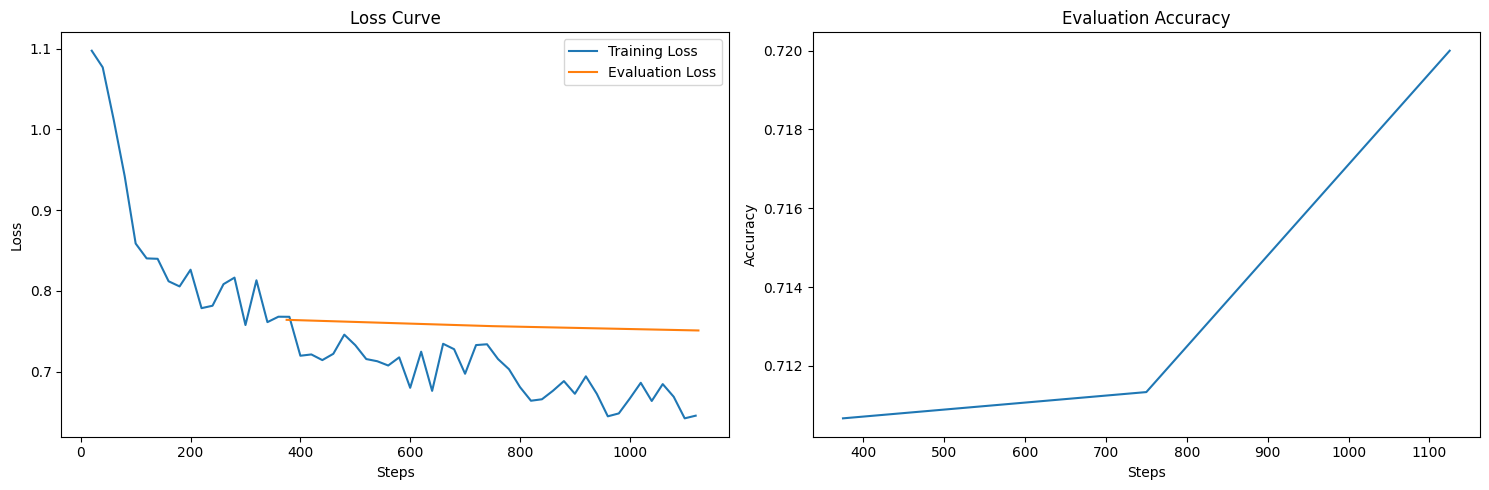

In [ ]:
import matplotlib.pyplot as plt

def plot_learning_curves(trainer):
    history = trainer.state.log_history

    # Separate training and evaluation logs
    train_logs = [log for log in history if 'loss' in log and 'eval_loss' not in log]
    eval_logs = [log for log in history if 'eval_loss' in log]

    plt.figure(figsize=(15, 5))

    # Plot loss
    plt.subplot(1, 2, 1)
    plt.plot([log['step'] for log in train_logs], [log['loss'] for log in train_logs], label='Training Loss')
    if eval_logs:
        plt.plot([log['step'] for log in eval_logs], [log['eval_loss'] for log in eval_logs], label='Evaluation Loss')
    plt.title('Loss Curve')
    plt.xlabel('Steps')
    plt.ylabel('Loss')
    plt.legend()

    # Plot other metrics (e.g., accuracy)
    plt.subplot(1, 2, 2)
    if eval_logs and any('eval_accuracy' in log for log in eval_logs):
        acc_logs = [log for log in eval_logs if 'eval_accuracy' in log]
        plt.plot([log['step'] for log in acc_logs], [log['eval_accuracy'] for log in acc_logs])
        plt.title('Evaluation Accuracy')
        plt.xlabel('Steps')
        plt.ylabel('Accuracy')

    plt.tight_layout()
    plt.show()

# Usage
plot_learning_curves(trainer)

After training, we generated a full performance report and a confusion matrix to visualize class-level prediction behavior.

#Interpretation

Classification report → Displays precision, recall, and F1-score for each rating (1★–5★).
This helps identify which star levels the model predicts confidently and which ones are commonly misclassified.

Confusion matrix → Provides a grid view of prediction errors.
Each row represents the true class, and each column represents the predicted class.
Darker diagonal cells indicate better accuracy for that rating, while off-diagonal cells reveal confusion between adjacent star levels.


Detailed classification report (labels 0..4 = stars 1..5):
              precision    recall  f1-score   support

           0      0.723     0.709     0.716      1000
           1      0.611     0.657     0.633      1000
           2      0.841     0.794     0.817      1000

    accuracy                          0.720      3000
   macro avg      0.725     0.720     0.722      3000
weighted avg      0.725     0.720     0.722      3000



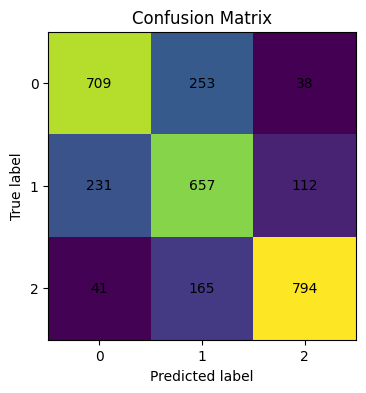

In [ ]:
# ---------- 7) Detailed report + confusion matrix ----------
pred = trainer.predict(tok_ds["test"])
y_true = pred.label_ids
y_pred = pred.predictions.argmax(-1)

print("\nDetailed classification report (labels 0..4 = stars 1..5):")
print(classification_report(y_true, y_pred, digits=3))

cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(5,4))
im = ax.imshow(cm, interpolation='nearest')
ax.set_title("Confusion Matrix")
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_xticks(range(3)); ax.set_yticks(range(3))
for i in range(3):
    for j in range(3):
        ax.text(j, i, cm[i, j], ha="center", va="center")
plt.show()


# strength
*  Class 2 shows excellent performance with 84.1% precision and 81.7% F1-score

*  Balanced performance across metrics - no major discrepancies between precision and recall

*  Consistent performance across all classes with macro and weighted averages matching

# Areas for Improvement

*    Class 1 is the most challenging with the lowest scores (61.1% precision, 63.3% F1)

*    Class 0 has moderate performance - room for improvement in both precision and recall

What This Means
Class-wise Analysis:

 *   Class 2 (Best): Model is very good at identifying this class and rarely confuses it with others

*   Class 0 (Medium): Reasonable performance but some confusion with other classes

 *   Class 1 (Most Difficult): Model struggles most with this class, likely getting confused with neighboring classes

Business Impact:

    The model correctly classifies ~720 out of every 1000 samples

    Best at identifying Class 2 patterns
